# Start Here

Welcome to the *Active Learning for bioacoustics* challenge.

This is an example notebook where you can evaluate your sampling method and export results for submissions. *You are free to adjust this notebook, however the results (.yaml) file must retain the correct format*.

Currently, this notebook runs the four baseline sampling strategies:
- `random` -- random sampling (challenge baseline)
- `margin_multilabel` -- uncertainty-based margin sampling
- `sklearn_coreset` -- diversity-based coreset selection
- `sklearn_typiclust` -- typicality clustering

**AULC** (Area Under the Learning Curve) for mAP (macro) is the primary metric:


In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import time

PROJECT_ROOT = Path().absolute().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

from core.active_learner import ActiveLearner

core.active_learner - INFO - Pre-warming UMAP (triggering numba JIT compilation)...
core.active_learner - INFO - UMAP pre-warming completed in 11.24376630783081


## Step 1: Setup Configuration

In [9]:
# ---------------------------------------------------------------------------
# Active Learning Configuration
# ---------------------------------------------------------------------------

# Participant info:
AUTHOR_LASTNAME = 'XX'      # NOTE: Lastname of the corresponding author
INSTITUTE_ABBREVIATION = 'AWI-VLIZ-WUR' # NOTE: Abbreviation of your institute or None

# AL loop parameters (Baseline default config)
N_CYCLES            = 15
EPOCHS_PER_CYCLE    = 10
BATCH_SIZE          = 32
N_SAMPLES_PER_CYCLE = 'higher_quantiles'    # NOTE: You can implement a scheduler

# Number of independent full-run repeats (each creates a fresh ActiveLearner
# with random model initialisation). Mean and SD are computed across these runs.
# NOTE: Submitted results must be run with N_REPEATS=5, use a lower value during development.
N_REPEATS = 5

# NOTE: Submitted results must be run with MAX_BUDGET=500.
MAX_BUDGET = 500

# Warm-up samples before the AL loop (None = cold start)
PRETRAIN_SAMPLES = 50

# Baseline strategies to compare. NOTE: When you are ready, add your sampling method here.
STRATEGIES = [
    "quantiles",
    "higher_quantiles",
    "best",
    "random",
    "sklearn_coreset",
]

WARMUPS = [
    "kmeans", 
    "eigenvalues", 
    "metadata"
]

#    "sklearn_typiclust"
#     "margin_multilabel"

print(f"Cycles            : {N_CYCLES}")
print(f"Samples per cycle : {N_SAMPLES_PER_CYCLE}")
print(f"Epochs per cycle  : {EPOCHS_PER_CYCLE}")
print(f"Outer repeats     : {N_REPEATS}  (independent runs, fresh model init each time)")
print(f"Max budget        : {MAX_BUDGET or 'none'}")
print(f"Strategies        : {STRATEGIES}")
print(f"Pretrain samples  : {PRETRAIN_SAMPLES or 'none'}")

Cycles            : 15
Samples per cycle : higher_quantiles
Epochs per cycle  : 10
Outer repeats     : 5  (independent runs, fresh model init each time)
Max budget        : 500
Strategies        : ['quantiles', 'higher_quantiles', 'best', 'random', 'sklearn_coreset']
Pretrain samples  : 50


## Step 2: Dataset paths

Set paths for the dataset. Adjust for the BirdSet subsets (HSN, POW, UHH) or ATBFL dataset.

In [6]:
MODEL_NAME     = "perch_v2"  # NOTE: Task 4 datasets will use "perch_v2" 
DATASET_NAME   = "/mnt/fscompute_shared/biodcase_AL26/ATBFL_BASEAL/ATBFL"    # NOTE: download the Task 4 datasets and set the path e.g. "BirdSet_BASEAL/POW_BASEAL"

EMBEDDINGS_DIR = PROJECT_ROOT / DATASET_NAME / "embeddings" / MODEL_NAME
LABELS_PATH    = PROJECT_ROOT / DATASET_NAME / "labels.csv"

print(f"Embeddings : {EMBEDDINGS_DIR}")
print(f"Labels     : {LABELS_PATH}")
print(f"Dataset    : {DATASET_NAME}  |  Model: {MODEL_NAME}")

Embeddings : /mnt/fscompute_shared/biodcase_AL26/ATBFL_BASEAL/ATBFL/embeddings/perch_v2
Labels     : /mnt/fscompute_shared/biodcase_AL26/ATBFL_BASEAL/ATBFL/labels.csv
Dataset    : /mnt/fscompute_shared/biodcase_AL26/ATBFL_BASEAL/ATBFL  |  Model: perch_v2


## Step 3: Run all baseline strategies

Each strategy runs the full AL loop with the shared configuration.
Results are collected in `results` for comparison and exported to `results/baselines/`.

In [10]:
results     = {}
all_learners = {}

OUTPUT_DIR = PROJECT_ROOT / "results" / "baselines"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_dataset_info_printed = False

for sampling_strategy in STRATEGIES:
    for warmup in WARMUPS:
        strategy = sampling_strategy + '_' + warmup
        print(f"\n{'='*60}")
        print(f"Strategy: {strategy}")
        print(f"{'='*60}")

        strategy_histories = []  # one training_history list per repeat

        for rep in range(N_REPEATS):
            print(f"\n  -- Repeat {rep + 1}/{N_REPEATS} --")

            # Fresh ActiveLearner each repeat -> random model re-initialisation.
            # repeats=1 disables the internal SD mechanism (handled by this outer loop).
            learner = ActiveLearner(
                embeddings_dir=EMBEDDINGS_DIR,
                annotations_path=LABELS_PATH,
                model_name=MODEL_NAME,
                dataset_name=DATASET_NAME,
                learning_rate=0.001,
                sampling_strategy=sampling_strategy,
                device="cpu",
                verbose=False,
                pretrain_samples=PRETRAIN_SAMPLES,
                warmup_method=warmup,
            )

            if not _dataset_info_printed:
                state = learner.get_state()
                print(f"\n  Dataset: {DATASET_NAME}  |  Total: {state['n_labeled'] + state['n_unlabeled']}  |  Classes: {state['num_classes']}\n")
                _dataset_info_printed = True

            print(f"  {'Cycle':>5}  {'Labelled':>8}  {'mAP':>8}  {'AULC':>8}")
            print(f"  {'-'*38}")
            if learner.training_history and learner.training_history[0].get('warmup', False):
                w = learner.training_history[0]
                print(f"  {'warmup':>5}  {w['n_labeled']:>8}  {w['mAP']:>8.4f}  {w['aulc_mAP']:>8.4f}")

            for cycle in range(N_CYCLES):
                start = time.time()
                if N_SAMPLES_PER_CYCLE == 'quantiles':
                    n_to_sample = state['num_classes'] * 4
                elif N_SAMPLES_PER_CYCLE == 'higher_quantiles':
                    n_to_sample = state['num_classes'] * 4
                else: 
                    n_to_sample = N_SAMPLES_PER_CYCLE
                if MAX_BUDGET is not None:
                    remaining = MAX_BUDGET - len(learner.labeled_indices)
                    if remaining <= 0:
                        print(f"  Budget of {MAX_BUDGET} reached -- stopping.")
                        break
                    n_to_sample = min(n_to_sample, remaining)

                selected = learner.sample(n_samples=n_to_sample)
                learner.add_samples(selected)
                metrics = learner.train_step(epochs=EPOCHS_PER_CYCLE, batch_size=BATCH_SIZE)
                print(f"  {cycle + 1:>5}  {metrics['n_labeled']:>8}  {metrics['mAP']:>8.4f}  {metrics['aulc_mAP']:>8.4f} {time.time() - start:>8.4f}")

            strategy_histories.append(learner.training_history)
            all_learners[strategy] = learner  # keep last for metadata

        results[strategy] = strategy_histories

        # Summary across repeats
        final_mAPs  = [h[-1]['mAP']       for h in strategy_histories]
        final_aulcs = [h[-1]['aulc_mAP']  for h in strategy_histories]
        print(f"\n  Final mAP : {np.mean(final_mAPs):.4f} +- {np.std(final_mAPs):.4f}")
        print(f"  Final AULC: {np.mean(final_aulcs):.4f} +- {np.std(final_aulcs):.4f}")


Strategy: quantiles_kmeans

  -- Repeat 1/5 --

  Dataset: /mnt/fscompute_shared/biodcase_AL26/ATBFL_BASEAL/ATBFL  |  Total: 12506  |  Classes: 8

  Cycle  Labelled       mAP      AULC
  --------------------------------------
  warmup        50    0.4208    0.2104
      1        82    0.4334    0.2950   0.5635
      2       114    0.4395    0.3347   0.6010
      3       146    0.4687    0.3609   0.6930
      4       178    0.4783    0.3811   0.5533
      5       210    0.4904    0.3969   0.7227
      6       242    0.5002    0.4099   1.4739
      7       274    0.5031    0.4206   1.1605
      8       306    0.5068    0.4294   0.9465
      9       338    0.5070    0.4367   1.2963
     10       370    0.5106    0.4430   1.5279
     11       402    0.5138    0.4485   1.4523
     12       434    0.5084    0.4531   1.2483
     13       466    0.5027    0.4567   1.8096
     14       498    0.5116    0.4599   1.4573
     15       500    0.5101    0.4601   1.7359

  -- Repeat 2/5 --
  Cycle  

## Step 4: Compare learning curves across strategies

In [11]:
def aggregate_histories(histories):
    """
    Aggregate a list of training histories (one per outer repeat) into
    per-cycle mean and SD.

    Args:
        histories: list of training_history lists, each of length N_CYCLES.

    Returns:
        List of dicts -- one entry per cycle -- with keys:
            cycle, n_labeled,
            mAP_mean, mAP_sd,
            aulc_mAP_mean, aulc_mAP_sd,
            annotation_cost,
            sampling_time_s_mean, sampling_time_s_sd
    """
    # Exclude warmup records (warmup=True) -- these have no training metrics
    histories = [[e for e in h if not e.get('warmup', False)] for h in histories]
    n_cycles = min(len(h) for h in histories)
    agg = []
    for c in range(n_cycles):
        entries = [h[c] for h in histories]
        mAPs  = np.array([e['mAP']         for e in entries])
        aulcs = np.array([e['aulc_mAP']    for e in entries])
        stimes = np.array([e.get('sampling_time_s', 0.0) for e in entries])
        agg.append({
            'cycle':              c + 1,
            'n_labeled':          entries[0]['n_labeled'],   # identical across repeats
            'mAP_mean':           float(np.mean(mAPs)),
            'mAP_sd':             float(np.std(mAPs)),
            'aulc_mAP_mean':      float(np.mean(aulcs)),
            'aulc_mAP_sd':        float(np.std(aulcs)),
            'annotation_cost':    entries[0].get('annotation_cost', 0),
            'sampling_time_s_mean': float(np.mean(stimes)),
            'sampling_time_s_sd':   float(np.std(stimes)),
        })
    return agg

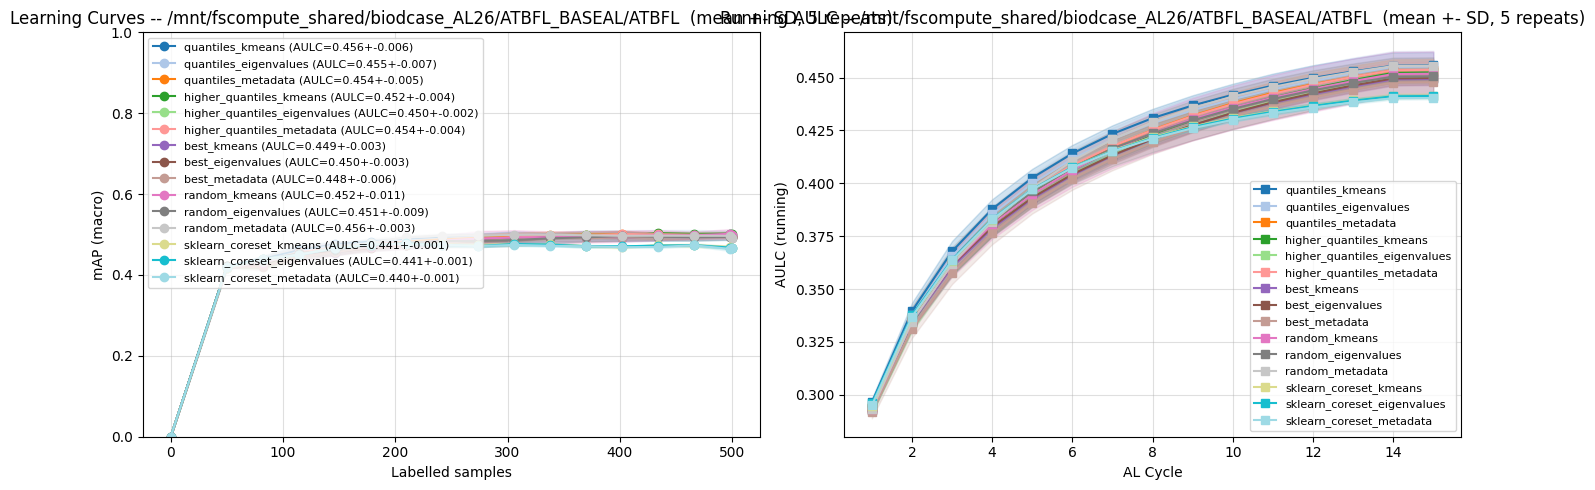


Final results -- /mnt/fscompute_shared/biodcase_AL26/ATBFL_BASEAL/ATBFL  (5 outer repeats)
Strategy                            mAP (mean+-SD)     AULC (mean+-SD)
------------------------------------------------------------------------
quantiles_kmeans                0.4931 +-0.0121  0.4558 +-0.0062
quantiles_eigenvalues           0.4985 +-0.0074  0.4552 +-0.0075
quantiles_metadata              0.4949 +-0.0080  0.4535 +-0.0052
higher_quantiles_kmeans         0.5007 +-0.0060  0.4524 +-0.0036
higher_quantiles_eigenvalues    0.4963 +-0.0059  0.4498 +-0.0022
higher_quantiles_metadata       0.4963 +-0.0068  0.4536 +-0.0040
best_kmeans                     0.4953 +-0.0051  0.4493 +-0.0030
best_eigenvalues                0.4947 +-0.0054  0.4498 +-0.0031
best_metadata                   0.4945 +-0.0030  0.4478 +-0.0058
random_kmeans                   0.4999 +-0.0108  0.4518 +-0.0105
random_eigenvalues              0.4911 +-0.0059  0.4505 +-0.0090
random_metadata                 0.4918 +-0.0065  

In [23]:
cmap = plt.get_cmap('tab20', len(results))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (strategy, histories), color in zip(results.items(), cmap.colors):
    agg = aggregate_histories(histories)

    # Include warmup anchor (pretrain_samples, 0.0) when warm-up was applied
    # Aggregate warmup mAP across repeats; origin always stays at (0, 0)
    _wu = [next((e for e in h if e.get('warmup', False)), None) for h in histories]
    _wu = [e for e in _wu if e is not None]
    if _wu:
        x_anchors  = [0, _wu[0]['n_labeled']]
        y_anchors  = [0.0, float(np.mean([e['mAP'] for e in _wu]))]
        sd_anchors = [0.0, float(np.std( [e['mAP'] for e in _wu]))]
    else:
        x_anchors  = [0]
        y_anchors  = [0.0]
        sd_anchors = [0.0]

    n_labeled   = np.array(x_anchors  + [a['n_labeled']    for a in agg])
    mAP_means   = np.array(y_anchors  + [a['mAP_mean']     for a in agg])
    mAP_sds     = np.array(sd_anchors + [a['mAP_sd']       for a in agg])
    aulc_means  = np.array([a['aulc_mAP_mean'] for a in agg])
    aulc_sds    = np.array([a['aulc_mAP_sd']  for a in agg])
    cycles      = np.arange(1, len(aulc_means) + 1)

    final_aulc_mean = agg[-1]['aulc_mAP_mean']
    final_aulc_sd   = agg[-1]['aulc_mAP_sd']
    label = f"{strategy} (AULC={final_aulc_mean:.3f}+-{final_aulc_sd:.3f})"

    # mAP learning curve
    axes[0].plot(n_labeled, mAP_means, marker='o', color=color, label=label)
    axes[0].fill_between(n_labeled,
                         mAP_means - mAP_sds,
                         mAP_means + mAP_sds,
                         alpha=0.2, color=color)

    # Running AULC curve
    axes[1].plot(cycles, aulc_means, marker='s', color=color, label=strategy)
    axes[1].fill_between(cycles,
                         aulc_means - aulc_sds,
                         aulc_means + aulc_sds,
                         alpha=0.2, color=color)

axes[0].set_xlabel('Labelled samples')
axes[0].set_ylabel('mAP (macro)')
axes[0].set_title(f'Learning Curves -- {DATASET_NAME}  (mean +- SD, {N_REPEATS} repeats)')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

axes[1].set_xlabel('AL Cycle')
axes[1].set_ylabel('AULC (running)')
axes[1].set_title(f'Running AULC -- {DATASET_NAME}  (mean +- SD, {N_REPEATS} repeats)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nFinal results -- {DATASET_NAME}  ({N_REPEATS} outer repeats)")
print(f"{'Strategy':<30}  {'mAP (mean+-SD)':>18}  {'AULC (mean+-SD)':>18}")
print("-" * 72)
for strategy, histories in results.items():
    agg = aggregate_histories(histories)
    final = agg[-1]
    print(f"{strategy:<30}  {final['mAP_mean']:>6.4f} +-{final['mAP_sd']:>6.4f}  "
          f"{final['aulc_mAP_mean']:>6.4f} +-{final['aulc_mAP_sd']:>6.4f}")

## Step 5: Exported files

Each strategy's results are written to `results/baselines/` as a YAML file.
Inspect these to determine an appropriate `MAX_BUDGET` and confirm baseline performance.

In [ ]:
import yaml
from datetime import datetime

_BASELINE_EPOCHS     = 10
_BASELINE_BATCH_SIZE = 32


def export_aggregated(strategy, histories, learner, output_path, max_budget=None):
    """
    Export aggregated (mean +- SD across outer repeats) results as a YAML file.

    The per-cycle learning curve contains mAP and AULC mean/SD, with the warmup
    step included as cycle 0. Supplementary fields include total annotation cost
    and sampling wall-time (mean +- SD across repeats) computed over all history
    entries (warmup + AL cycles) and the standard computational cost ratio.
    """
    agg = aggregate_histories(histories)
    model_parameters = int(sum(p.numel() for p in learner.model.parameters()))
    n_cycles = len(agg)
    epochs_per_cycle = EPOCHS_PER_CYCLE

    # Warmup entries (one per outer repeat)
    warmup_entries = [next((e for e in h if e.get('warmup', False)), None) for h in histories]
    warmup_entries = [e for e in warmup_entries if e is not None]

    # Per-cycle rows: warmup as cycle 0, then AL cycles
    learning_curve = []
    if warmup_entries:
        wu_stimes = [e.get('sampling_time_s', 0.0) for e in warmup_entries]
        learning_curve.append({
            'cycle':                 0,
            'warmup':                True,
            'n_labeled':             warmup_entries[0]['n_labeled'],
            'mAP_mean':              round(float(np.mean([e['mAP']      for e in warmup_entries])), 6),
            'mAP_sd':                round(float(np.std( [e['mAP']      for e in warmup_entries])), 6),
            'aulc_mAP_mean':         round(float(np.mean([e['aulc_mAP'] for e in warmup_entries])), 6),
            'aulc_mAP_sd':           round(float(np.std( [e['aulc_mAP'] for e in warmup_entries])), 6),
            'annotation_cost':       warmup_entries[0].get('annotation_cost', 0),
            'sampling_time_s_mean':  round(float(np.mean(wu_stimes)), 6),
            'sampling_time_s_sd':    round(float(np.std(wu_stimes)),  6),
        })

    for a in agg:
        learning_curve.append({
            'cycle':                 a['cycle'],
            'n_labeled':             a['n_labeled'],
            'mAP_mean':              round(a['mAP_mean'],          6),
            'mAP_sd':                round(a['mAP_sd'],            6),
            'aulc_mAP_mean':         round(a['aulc_mAP_mean'],     6),
            'aulc_mAP_sd':           round(a['aulc_mAP_sd'],       6),
            'annotation_cost':       a['annotation_cost'],
            'sampling_time_s_mean':  round(a['sampling_time_s_mean'], 6),
            'sampling_time_s_sd':    round(a['sampling_time_s_sd'],   6),
        })

    # Aggregate annotation cost and sampling time across ALL history entries (warmup + AL cycles)
    total_ann_costs = [
        sum(e.get('annotation_cost', 0) for e in h)
        for h in histories
    ]
    total_stimes = [
        sum(e.get('sampling_time_s', 0.0) for e in h)
        for h in histories
    ]

    # Computational cost
    baseline_n_cycles = max_budget // _BASELINE_BATCH_SIZE if max_budget else n_cycles
    cost_method   = model_parameters * epochs_per_cycle * n_cycles
    baseline_cost = model_parameters * _BASELINE_EPOCHS * baseline_n_cycles
    relative_cost = round(cost_method / baseline_cost, 4) if baseline_cost > 0 else None

    submission = {
        'submission_timestamp':   datetime.now().isoformat(timespec='seconds'),
        'author_lastname':        AUTHOR_LASTNAME,
        'institute_abbreviation': INSTITUTE_ABBREVIATION,
        'sampling_strategy':      strategy,
        'dataset':                DATASET_NAME,
        'model':                  MODEL_NAME,
        'config': {
            'learning_rate':      learner.learning_rate,
            'model_parameters':   model_parameters,
            'n_outer_repeats':    N_REPEATS,
            'pretrain_samples':   learner.pretrain_samples,
            'warmup_strategy':   learner.warmup_strategy.method,
        },
        'learning_curve': learning_curve,
        'supplementary': {
            'n_cycles':                       n_cycles,
            'n_outer_repeats':                N_REPEATS,
            'total_annotation_cost_mean':     round(float(np.mean(total_ann_costs)), 2),
            'total_annotation_cost_sd':       round(float(np.std(total_ann_costs)),  2),
            'total_sampling_time_s_mean':     round(float(np.mean(total_stimes)),    6),
            'total_sampling_time_s_sd':       round(float(np.std(total_stimes)),     6),
            'computational_cost': {
                'model_parameters':   model_parameters,
                'epochs_per_cycle':   epochs_per_cycle,
                'n_cycles':           n_cycles,
                'cost_method':        cost_method,
                'baseline_n_cycles':  baseline_n_cycles,
                'baseline_cost':      baseline_cost,
                'relative_cost':      relative_cost,
            },
        },
    }

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, 'w') as f:
        yaml.dump(submission, f, default_flow_style=False, sort_keys=False, allow_unicode=True)
    print(f"  Saved: {Path(output_path).name}")


print(f"Files saved to: {PROJECT_ROOT / 'results' / 'baselines'}\n")
for strategy in STRATEGIES:
    safe_name = DATASET_NAME.replace('/', '_')
    output_file = OUTPUT_DIR / f"{strategy}_{safe_name}.yaml"
    export_aggregated(
        strategy=strategy,
        histories=results[strategy],
        learner=all_learners[strategy],
        output_path=str(output_file),
        max_budget=MAX_BUDGET,
    )

## Notes

- `MAX_BUDGET = None` the loop runs for exactly `N_CYCLES`
- `N_SAMPLES_PER_CYCLE` samples with no cap.
  Set `MAX_BUDGET` to a specific value once an appropriate budget has been determined from these results.
- All four strategies use the same `learning_rate`, `epochs`, and `batch_size` to ensure fair comparison.
- The YAML exports in `results/baselines/` contain the full learning curve and can be used to set
  `MAX_BUDGET` in the challenge participant notebooks.